In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
processed_folder = Path("../data/processed")
figures_folder = Path("../figures")
figures_folder.mkdir(parents=True, exist_ok=True)

In [3]:
bank_files = {
    "CBA": "CBA_clean.csv",
    "NAB": "NAB_clean.csv",
    "WBC": "WBC_clean.csv",
    "ANZ": "ANZ_clean.csv",
    "MQG": "MQG_clean.csv"
}

In [4]:
banks = {}

for bank, filename in bank_files.items():

    file_path = processed_folder / filename

    df = pd.read_csv(file_path)
    df["Date"] = pd.to_datetime(
        df["Date"],
        errors="coerce"
    )

    df["Adj Close"] = pd.to_numeric(
        df["Adj Close"],
        errors="coerce"
    )
    df = df.dropna(subset=["Date", "Adj Close"])
    df = df.sort_values("Date")
    df = df.reset_index(drop=True)

    banks[bank] = df
    print(
        bank,
        ":",
        len(df),
        "rows loaded"
    )

CBA : 6349 rows loaded
NAB : 6349 rows loaded
WBC : 6349 rows loaded
ANZ : 6349 rows loaded
MQG : 6349 rows loaded


In [5]:
for bank, df in banks.items():
    print(f"\n{bank}")
    print("First date:", df["Date"].min())
    print("Last date :", df["Date"].max())
    print("Rows      :", len(df))


CBA
First date: 2001-07-30 00:00:00
Last date : 2026-07-28 00:00:00
Rows      : 6349

NAB
First date: 2001-07-30 00:00:00
Last date : 2026-07-28 00:00:00
Rows      : 6349

WBC
First date: 2001-07-30 00:00:00
Last date : 2026-07-28 00:00:00
Rows      : 6349

ANZ
First date: 2001-07-30 00:00:00
Last date : 2026-07-28 00:00:00
Rows      : 6349

MQG
First date: 2001-07-30 00:00:00
Last date : 2026-07-28 00:00:00
Rows      : 6349


In [6]:
price_tables = []
for bank, df in banks.items():

    bank_prices = df[
        ["Date", "Adj Close"]
    ].copy()

    bank_prices = bank_prices.rename(
        columns={"Adj Close": bank}
    )

    bank_prices = bank_prices.set_index("Date")

    price_tables.append(bank_prices)

price_df = pd.concat(
    price_tables,
    axis=1,
    join="inner"
)

price_df = price_df.sort_index()
price_df.head()

,CBA,NAB,WBC,ANZ,MQG
Date,,,,,
2001-07-30,8.296802,7.551603,3.621745,3.909603,11.551105
2001-07-31,8.196772,7.650812,3.567105,3.838204,11.730391
2001-08-01,8.438504,7.865762,3.637354,3.963766,11.486030
2001-08-02,8.477962,7.960246,3.681584,3.988384,11.795137
2001-08-03,8.299582,7.983869,3.709685,4.086864,11.827676


In [7]:
print("Shape:", price_df.shape)
print("First date:", price_df.index.min())
print("Last date :", price_df.index.max())

print("\nMissing values:")
print(price_df.isnull().sum())

Shape: (6349, 5)
First date: 2001-07-30 00:00:00
Last date : 2026-07-28 00:00:00

Missing values:
CBA    0
NAB    0
WBC    0
ANZ    0
MQG    0
dtype: int64


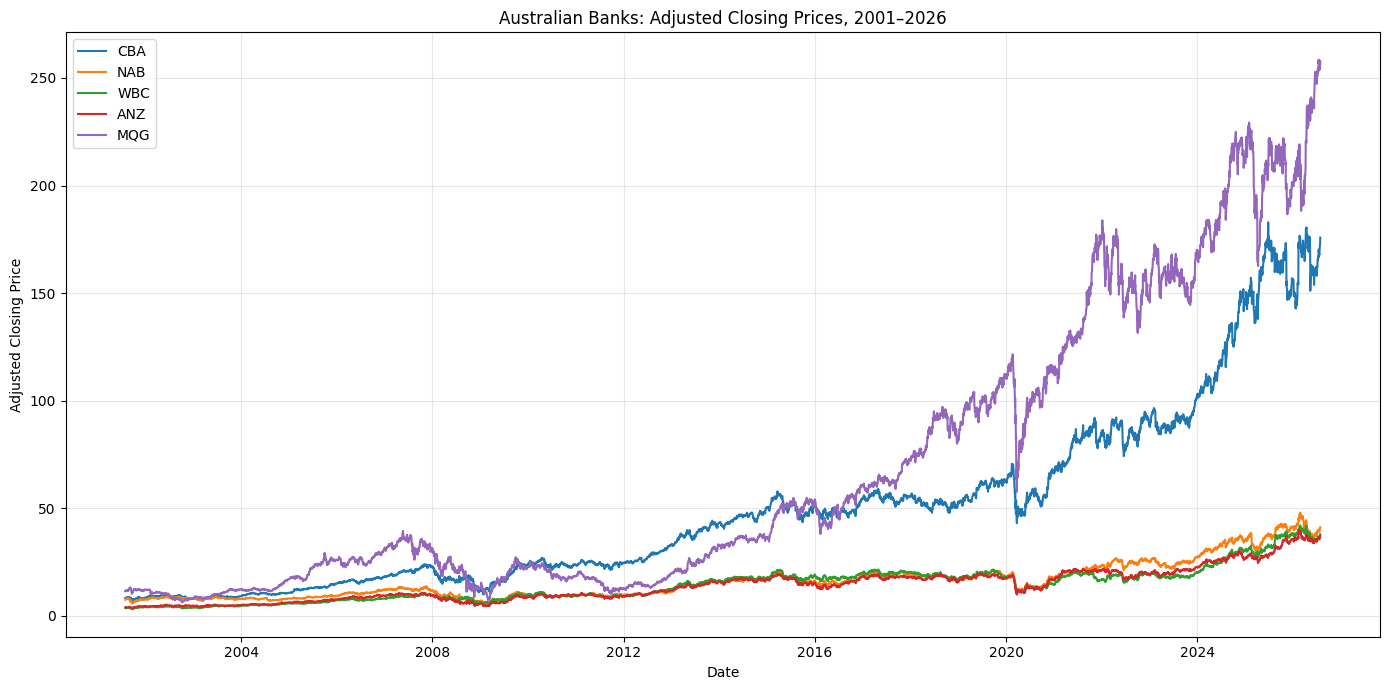

In [8]:
plt.figure(figsize=(14, 7))
for bank in price_df.columns:

    plt.plot(
        price_df.index,
        price_df[bank],
        label=bank
    )

plt.title(
    "Australian Banks: Adjusted Closing Prices, 2001–2026"
)

plt.xlabel("Date")
plt.ylabel("Adjusted Closing Price")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    figures_folder / "adjusted_price_history.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [9]:
normalised_prices = (
    price_df / price_df.iloc[0]
) * 100

normalised_prices.head()

,CBA,NAB,WBC,ANZ,MQG
Date,,,,,
2001-07-30,100.000000,100.000000,100.000000,100.000000,100.000000
2001-07-31,98.794355,101.313739,98.491340,98.173748,101.552103
2001-08-01,101.707919,104.160155,100.430987,101.385383,99.436626
2001-08-02,102.183503,105.411338,101.652235,102.015049,102.112628
2001-08-03,100.033518,105.724152,102.428118,104.533968,102.394319


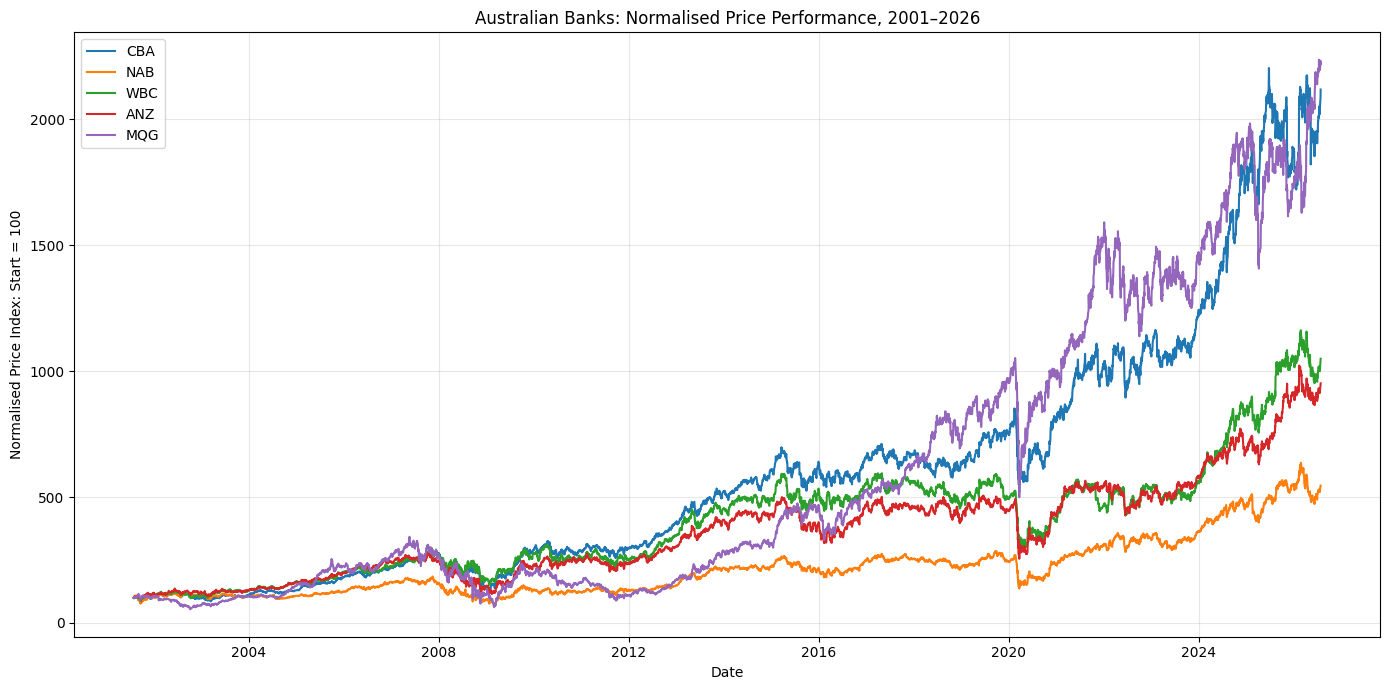

In [10]:
plt.figure(figsize=(14, 7))

for bank in normalised_prices.columns:

    plt.plot(
        normalised_prices.index,
        normalised_prices[bank],
        label=bank
    )

plt.title(
    "Australian Banks: Normalised Price Performance, 2001–2026"
)

plt.xlabel("Date")
plt.ylabel("Normalised Price Index: Start = 100")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    figures_folder / "normalised_price_history.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [11]:
returns = price_df.pct_change(
    fill_method=None
)

returns = returns.dropna()

returns.head()

,CBA,NAB,WBC,ANZ,MQG
Date,,,,,
2001-07-31,-0.012056,0.013137,-0.015087,-0.018263,0.015521
2001-08-01,0.029491,0.028095,0.019694,0.032714,-0.020831
2001-08-02,0.004676,0.012012,0.012160,0.006211,0.026912
2001-08-03,-0.021040,0.002968,0.007633,0.024692,0.002759
2001-08-06,0.018413,0.002071,0.002244,-0.003012,0.010179


In [12]:
log_returns = np.log(
    price_df / price_df.shift(1)
)

log_returns = log_returns.dropna()
log_returns.head()

,CBA,NAB,WBC,ANZ,MQG
Date,,,,,
2001-07-31,-0.012130,0.013052,-0.015202,-0.018431,0.015402
2001-08-01,0.029065,0.027708,0.019502,0.032190,-0.021051
2001-08-02,0.004665,0.011941,0.012087,0.006191,0.026556
2001-08-03,-0.021265,0.002963,0.007604,0.024392,0.002755
2001-08-06,0.018245,0.002069,0.002242,-0.003017,0.010127


In [13]:
returns.to_csv(
    processed_folder / "daily_returns.csv",
    index=True
)

log_returns.to_csv(
    processed_folder / "log_returns.csv",
    index=True
)

print("Daily returns and log returns saved.")

Daily returns and log returns saved.


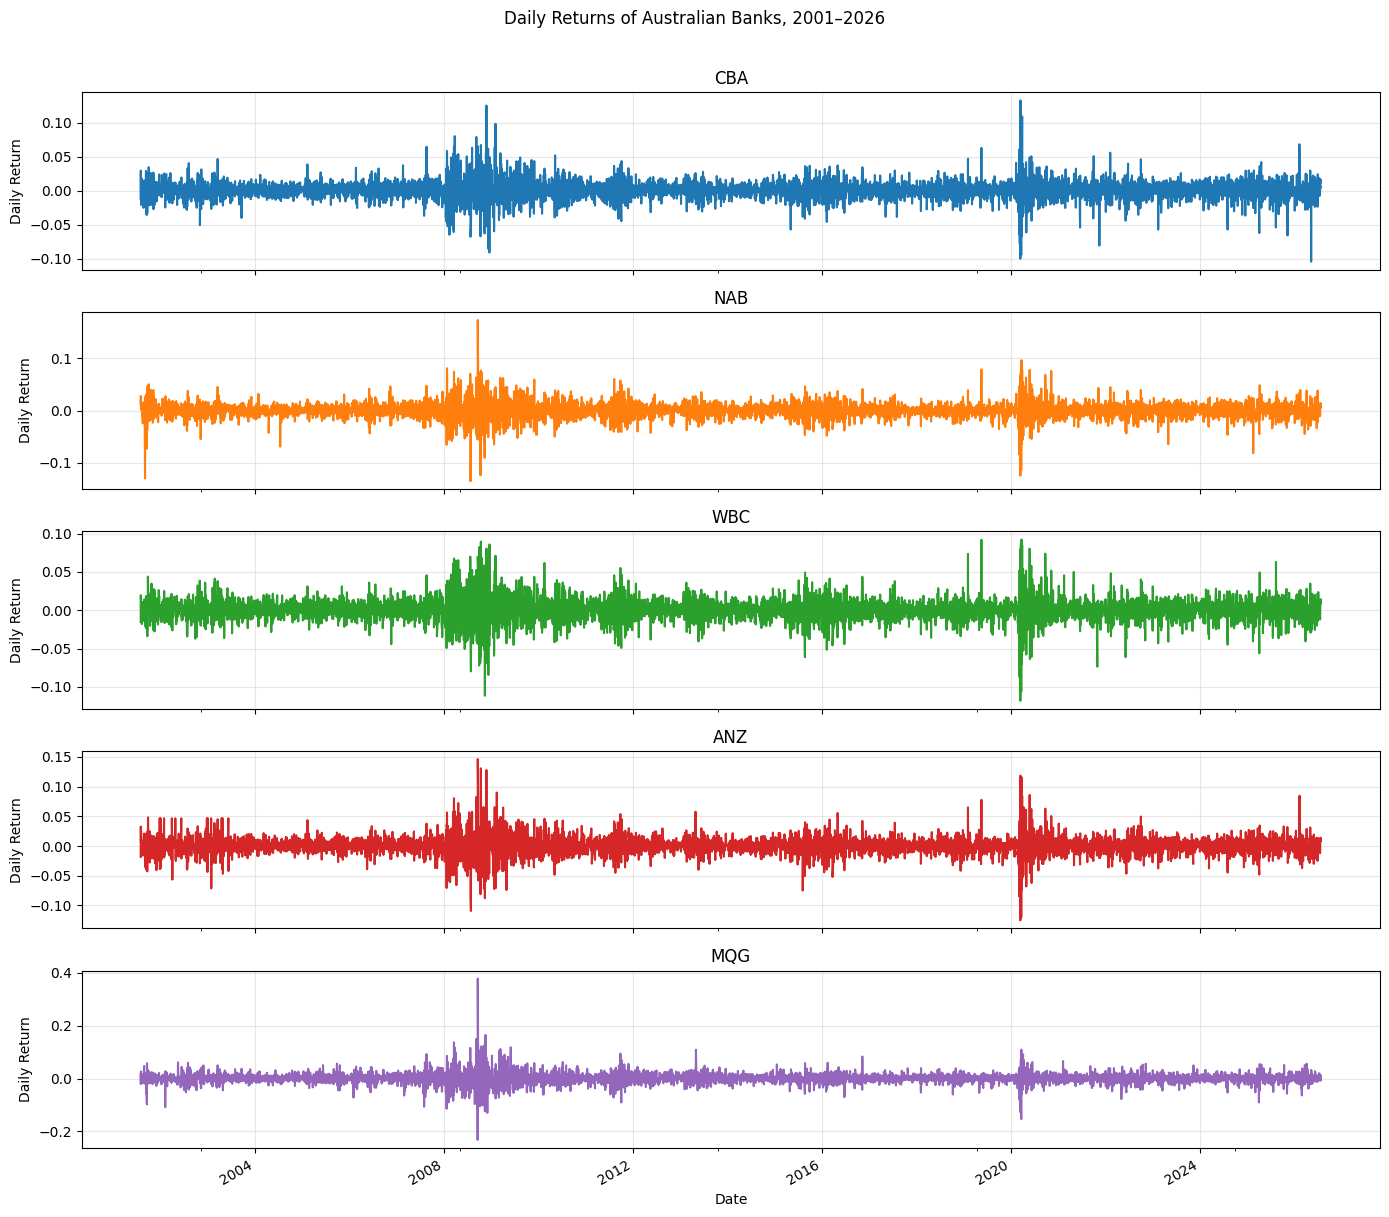

In [14]:
axes = returns.plot(
    subplots=True,
    figsize=(14, 12),
    sharex=True,
    legend=False
)

for axis, bank in zip(
    axes,
    returns.columns
):

    axis.set_title(bank)
    axis.set_ylabel("Daily Return")
    axis.grid(alpha=0.3)

plt.suptitle(
    "Daily Returns of Australian Banks, 2001–2026",
    y=1.01
)

plt.tight_layout()
plt.savefig(
    figures_folder / "daily_returns.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [15]:
return_summary = returns.describe().T
return_summary["Annualised Volatility"] = (
    returns.std() * np.sqrt(252)
)
return_summary

,count,mean,std,min,25%,50%,75%,max,Annualised Volatility
CBA,6348.0,0.000577,0.013827,-0.104331,-0.006123,0.000615,0.007638,0.132619,0.219499
NAB,6348.0,0.000381,0.015086,-0.134853,-0.006470,0.000570,0.007564,0.173470,0.239483
WBC,6348.0,0.000479,0.014720,-0.118101,-0.006824,0.000582,0.007814,0.092350,0.233679
ANZ,6348.0,0.000472,0.015321,-0.125000,-0.006718,0.000746,0.007750,0.146279,0.243219
MQG,6348.0,0.000697,0.020457,-0.232243,-0.008043,0.000697,0.009864,0.378119,0.324745


In [16]:
annualised_volatility = (
    returns.std()
    * np.sqrt(252)
)

annualised_volatility = (
    annualised_volatility
    .sort_values(ascending=False)
)

annualised_volatility

MQG    0.324745
ANZ    0.243219
NAB    0.239483
WBC    0.233679
CBA    0.219499
dtype: float64

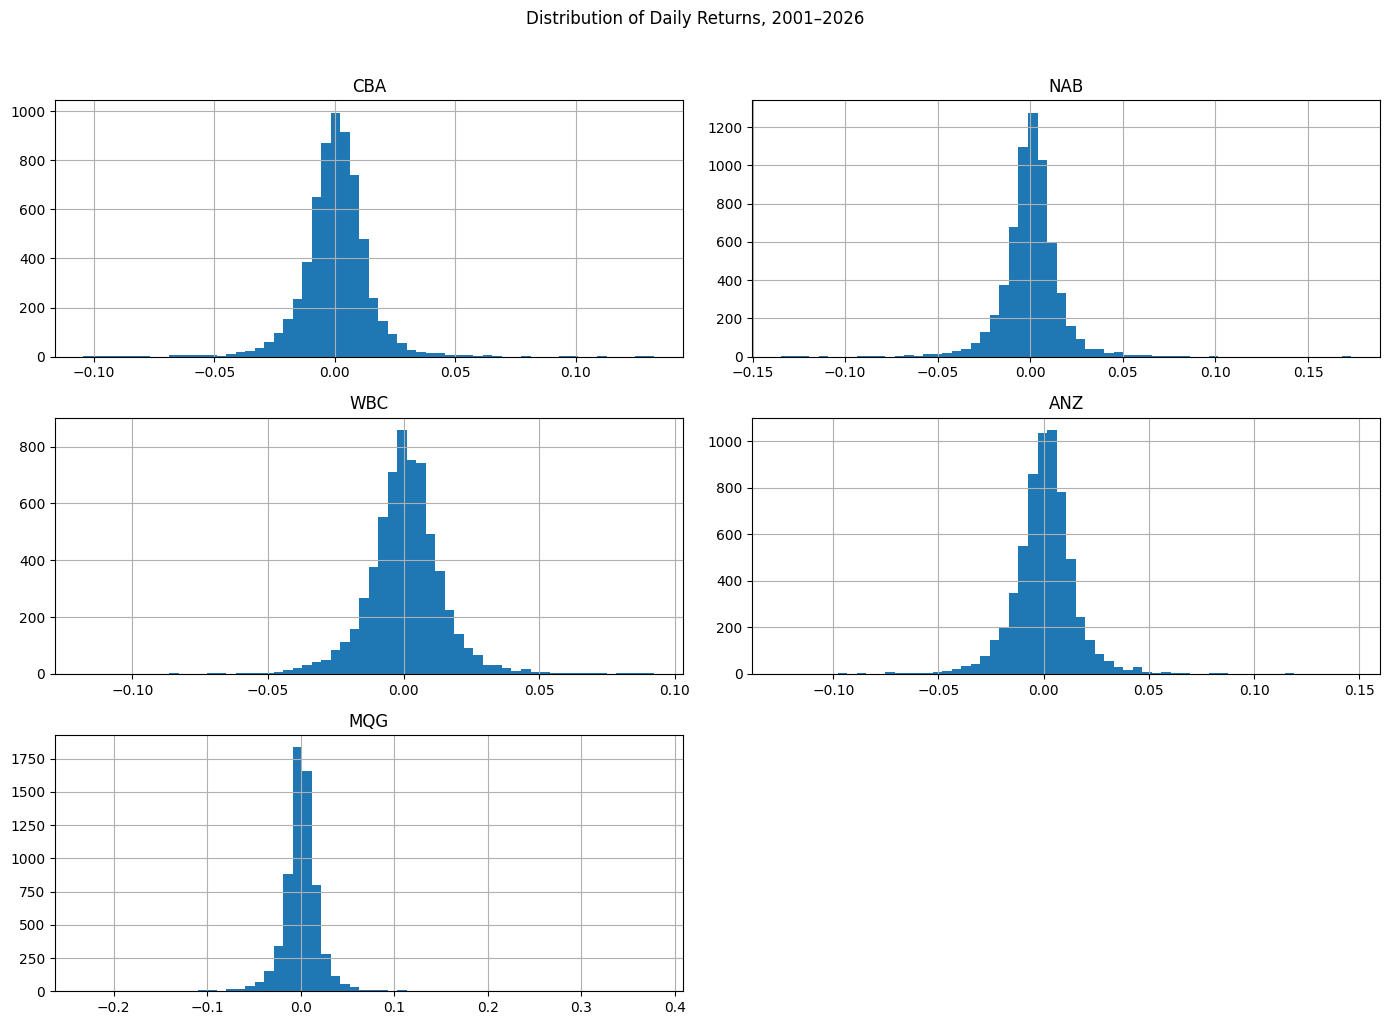

In [17]:
returns.hist(
    figsize=(14, 10),
    bins=60
)

plt.suptitle(
    "Distribution of Daily Returns, 2001–2026",
    y=1.02
)

plt.tight_layout()
plt.savefig(
    figures_folder / "return_histograms.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

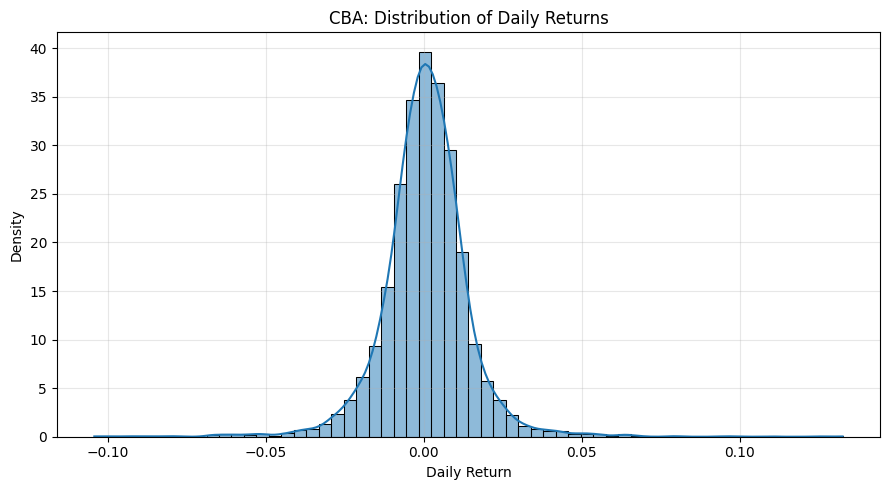

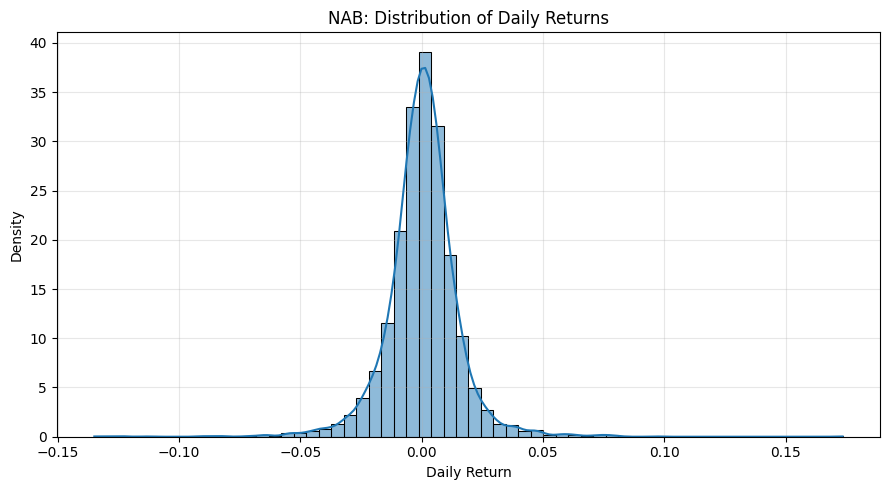

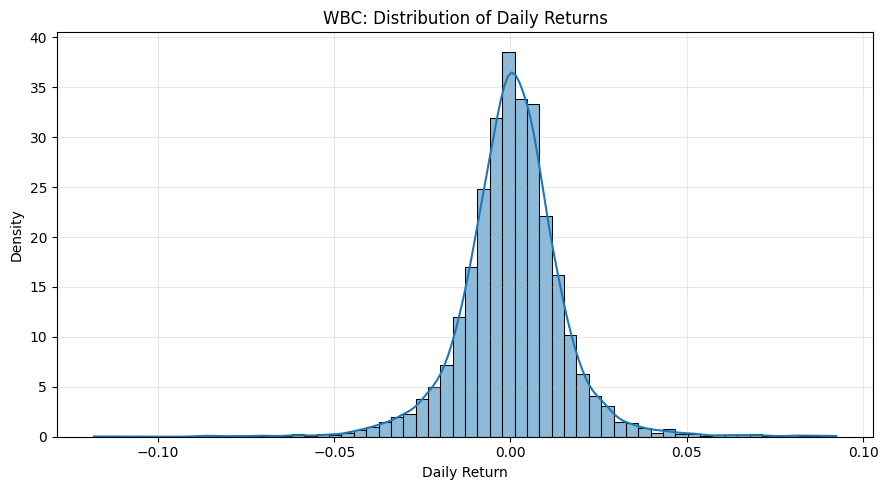

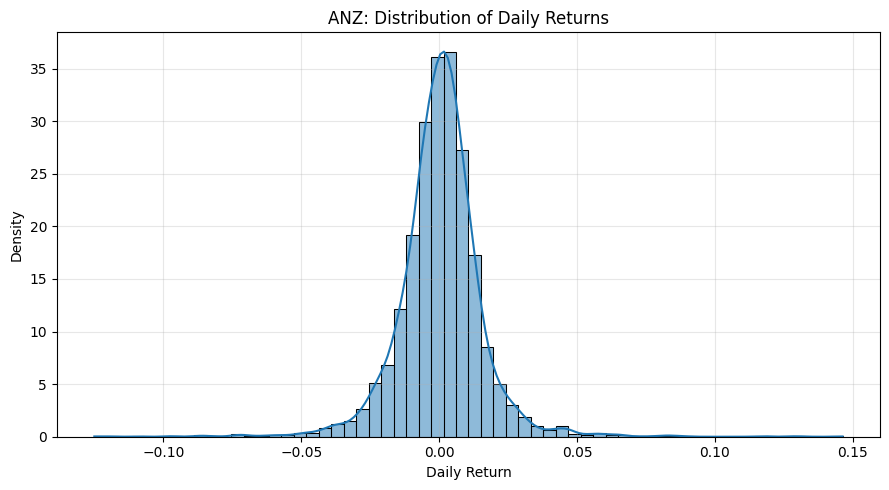

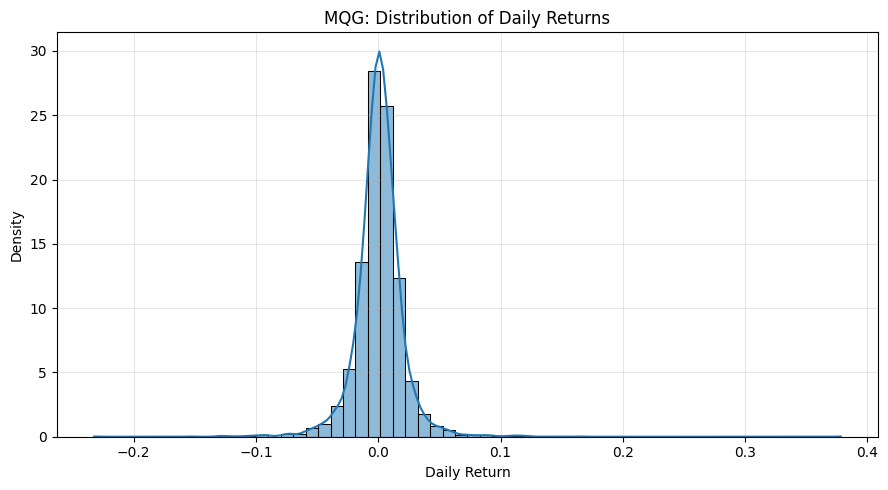

In [18]:
for bank in returns.columns:
    plt.figure(figsize=(9, 5))
    sns.histplot(
        returns[bank],
        bins=60,
        kde=True,
        stat="density"
    )

    plt.title(
        f"{bank}: Distribution of Daily Returns"
    )

    plt.xlabel("Daily Return")
    plt.ylabel("Density")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(
        figures_folder / f"{bank}_return_distribution.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [19]:
distribution_summary = pd.DataFrame({
    "Mean": returns.mean(),
    "Standard Deviation": returns.std(),
    "Skewness": returns.skew(),
    "Kurtosis": returns.kurt(),
    "Minimum Return": returns.min(),
    "Maximum Return": returns.max()
})

distribution_summary

,Mean,Standard Deviation,Skewness,Kurtosis,Minimum Return,Maximum Return
CBA,0.000577,0.013827,0.083417,8.535549,-0.104331,0.132619
NAB,0.000381,0.015086,-0.171632,10.267087,-0.134853,0.173470
WBC,0.000479,0.014720,-0.075154,6.244230,-0.118101,0.092350
ANZ,0.000472,0.015321,0.158070,9.567138,-0.125000,0.146279
MQG,0.000697,0.020457,0.733682,27.690783,-0.232243,0.378119


In [20]:

distribution_summary.to_csv(
    processed_folder / "descriptive_statistics.csv"
)
print("Descriptive statistics saved successfully.")

Descriptive statistics saved successfully.


In [21]:
correlation_matrix = returns.corr()

correlation_matrix

,CBA,NAB,WBC,ANZ,MQG
CBA,1.000000,0.737385,0.758090,0.721336,0.520743
NAB,0.737385,1.000000,0.755497,0.760341,0.582601
WBC,0.758090,0.755497,1.000000,0.790770,0.527384
ANZ,0.721336,0.760341,0.790770,1.000000,0.554434
MQG,0.520743,0.582601,0.527384,0.554434,1.000000


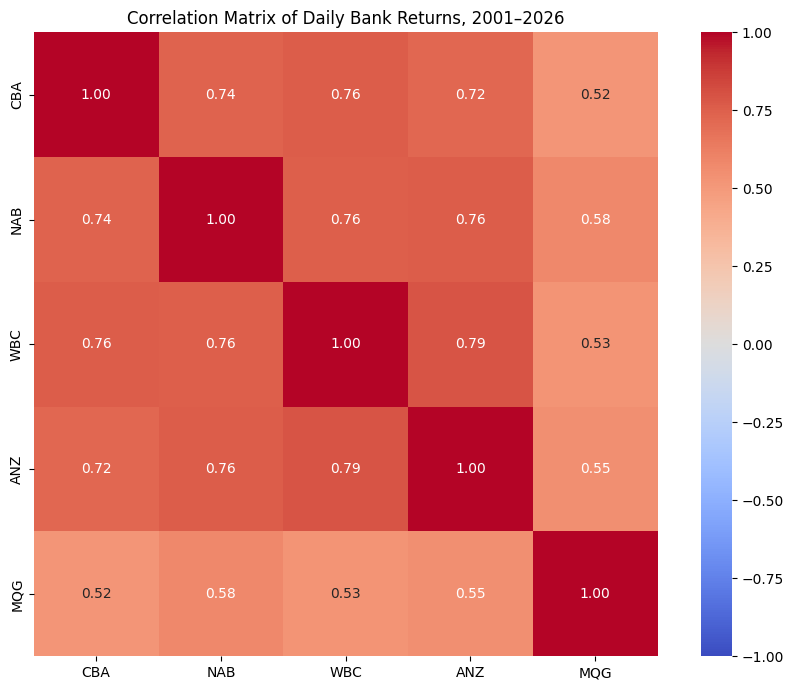

In [22]:
plt.figure(figsize=(9, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    vmin=-1,
    vmax=1,
    cmap="coolwarm",
    square=True
)

plt.title(
    "Correlation Matrix of Daily Bank Returns, 2001–2026"
)

plt.tight_layout()
plt.savefig(
    figures_folder / "return_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
rolling_volatility = (
    returns
    .rolling(window=30)
    .std()
    * np.sqrt(252)
)

rolling_volatility.head(35)

,CBA,NAB,WBC,ANZ,MQG
Date,,,,,
2001-07-31,NaN,NaN,NaN,NaN,NaN
2001-08-01,NaN,NaN,NaN,NaN,NaN
2001-08-02,NaN,NaN,NaN,NaN,NaN
2001-08-03,NaN,NaN,NaN,NaN,NaN
2001-08-06,NaN,NaN,NaN,NaN,NaN
2001-08-07,NaN,NaN,NaN,NaN,NaN
2001-08-08,NaN,NaN,NaN,NaN,NaN
2001-08-09,NaN,NaN,NaN,NaN,NaN
2001-08-10,NaN,NaN,NaN,NaN,NaN


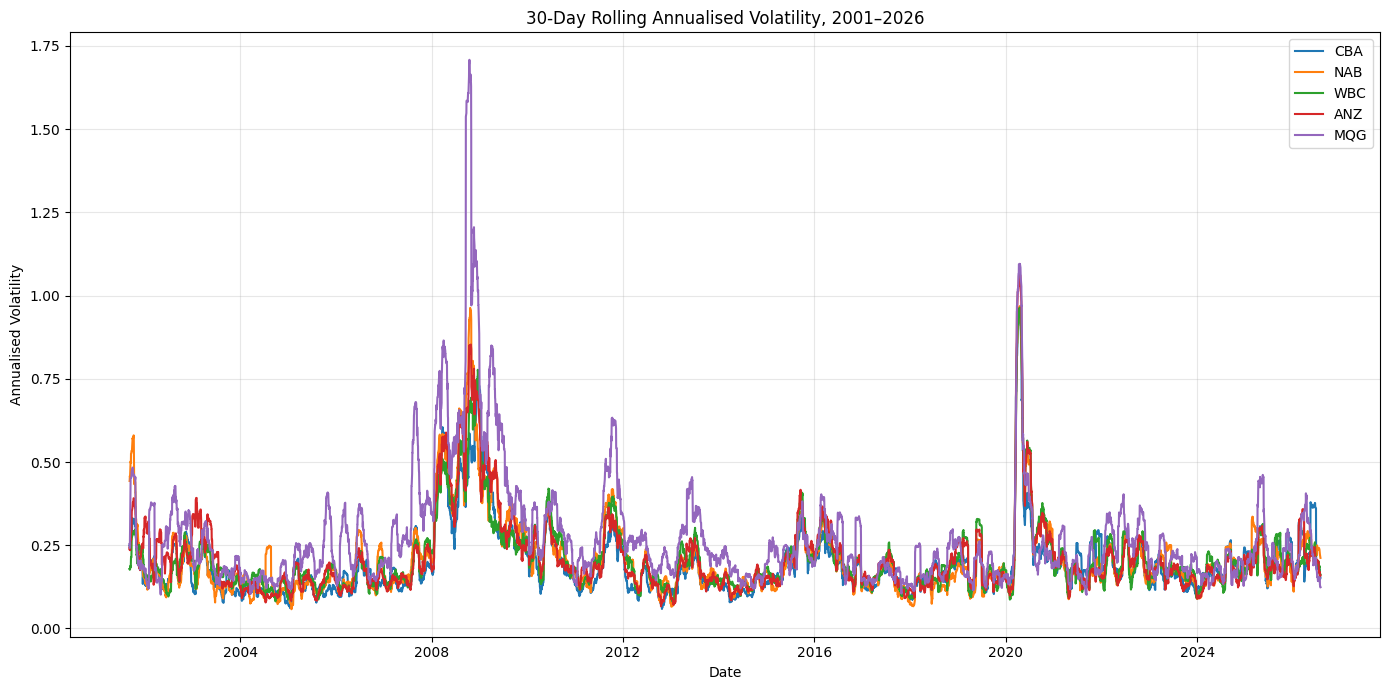

In [24]:
plt.figure(figsize=(14, 7))

for bank in rolling_volatility.columns:

    plt.plot(
        rolling_volatility.index,
        rolling_volatility[bank],
        label=bank
    )

plt.title(
    "30-Day Rolling Annualised Volatility, 2001–2026"
)

plt.xlabel("Date")
plt.ylabel("Annualised Volatility")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    figures_folder / "rolling_volatility.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
rolling_volatility.to_csv(
    processed_folder / "rolling_volatility.csv",
    index=True
)

print("Rolling volatility saved.")

Rolling volatility saved.


In [26]:
event_windows = {
    "Dot-com aftermath": (
        "2001-07-30",
        "2002-12-31"
    ),

    "Global Financial Crisis": (
        "2007-07-01",
        "2009-06-30"
    ),

    "European Debt Crisis": (
        "2010-01-01",
        "2012-12-31"
    ),

    "COVID-19 crash": (
        "2020-02-01",
        "2020-06-30"
    ),

    "Inflation and RBA tightening": (
        "2022-01-01",
        "2023-12-31"
    ),

    "SVB and Credit Suisse": (
        "2023-03-01",
        "2023-04-30"
    )
}

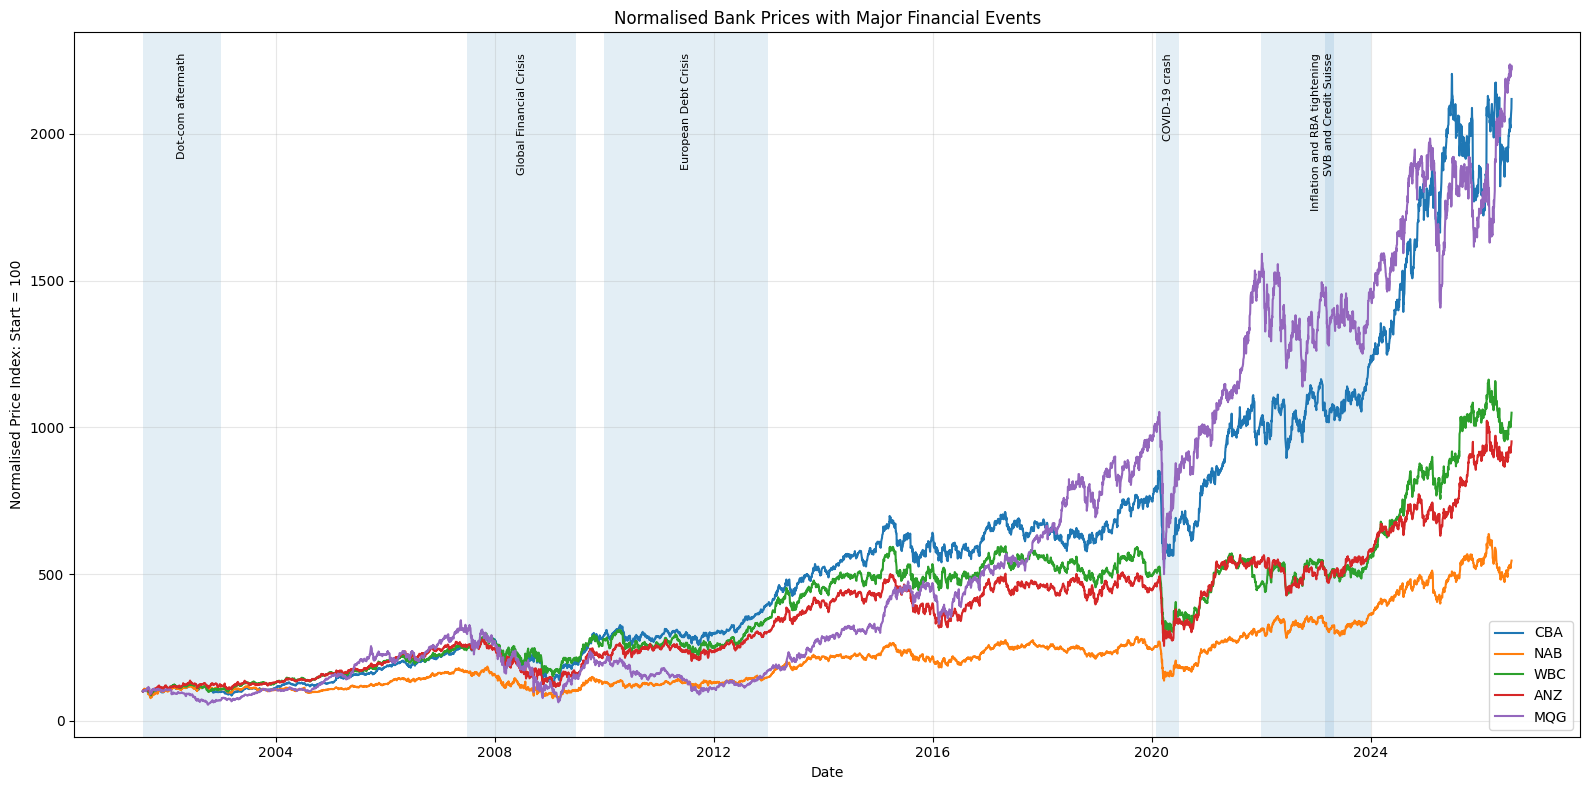

In [27]:
plt.figure(figsize=(16, 8))
for bank in normalised_prices.columns:
    plt.plot(
        normalised_prices.index,
        normalised_prices[bank],
        label=bank
    )

for event, (start, end) in event_windows.items():
    start_date = pd.to_datetime(start)
    end_date = pd.to_datetime(end)

    plt.axvspan(
        start_date,
        end_date,
        alpha=0.12
    )

    midpoint = start_date + (end_date - start_date) / 2

    plt.text(
        midpoint,
        plt.ylim()[1] * 0.97,
        event,
        rotation=90,
        ha="center",
        va="top",
        fontsize=8
    )

plt.title(
    "Normalised Bank Prices with Major Financial Events"
)

plt.xlabel("Date")
plt.ylabel("Normalised Price Index: Start = 100")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
event_volatility_results = {}
for event, dates in event_windows.items():
    start, end = dates
    event_returns = returns.loc[
        start:end
    ]

    event_volatility = (
        event_returns.std()
        * np.sqrt(252)
    )

    event_volatility_results[event] = (
        event_volatility
    )

event_volatility_table = pd.DataFrame(
    event_volatility_results
).T

event_volatility_table

,CBA,NAB,WBC,ANZ,MQG
Dot-com aftermath,0.204333,0.248432,0.196885,0.249166,0.293711
Global Financial Crisis,0.407327,0.461224,0.417377,0.463913,0.742165
European Debt Crisis,0.182999,0.219224,0.224351,0.207188,0.303401
COVID-19 crash,0.570330,0.624159,0.629842,0.670532,0.666950
Inflation and RBA tightening,0.182625,0.192406,0.194377,0.188342,0.253933
SVB and Credit Suisse,0.152306,0.201831,0.175744,0.180246,0.250788


In [29]:
event_volatility_table[
    "Average Across Banks"
] = event_volatility_table.mean(axis=1)

event_volatility_table.sort_values(
    "Average Across Banks",
    ascending=False
)

,CBA,NAB,WBC,ANZ,MQG,Average Across Banks
COVID-19 crash,0.570330,0.624159,0.629842,0.670532,0.666950,0.632363
Global Financial Crisis,0.407327,0.461224,0.417377,0.463913,0.742165,0.498401
Dot-com aftermath,0.204333,0.248432,0.196885,0.249166,0.293711,0.238505
European Debt Crisis,0.182999,0.219224,0.224351,0.207188,0.303401,0.227433
Inflation and RBA tightening,0.182625,0.192406,0.194377,0.188342,0.253933,0.202337
SVB and Credit Suisse,0.152306,0.201831,0.175744,0.180246,0.250788,0.192183


In [30]:
event_correlations = {}
for event, dates in event_windows.items():

    start, end = dates

    event_returns = returns.loc[
        start:end
    ]

    event_correlations[event] = (
        event_returns.corr()
    )

In [31]:
event_correlations["Global Financial Crisis"]
event_correlations["COVID-19 crash"]


,CBA,NAB,WBC,ANZ,MQG
CBA,1.000000,0.882823,0.885861,0.915782,0.764511
NAB,0.882823,1.000000,0.973479,0.967459,0.832722
WBC,0.885861,0.973479,1.000000,0.978015,0.818449
ANZ,0.915782,0.967459,0.978015,1.000000,0.831439
MQG,0.764511,0.832722,0.818449,0.831439,1.000000


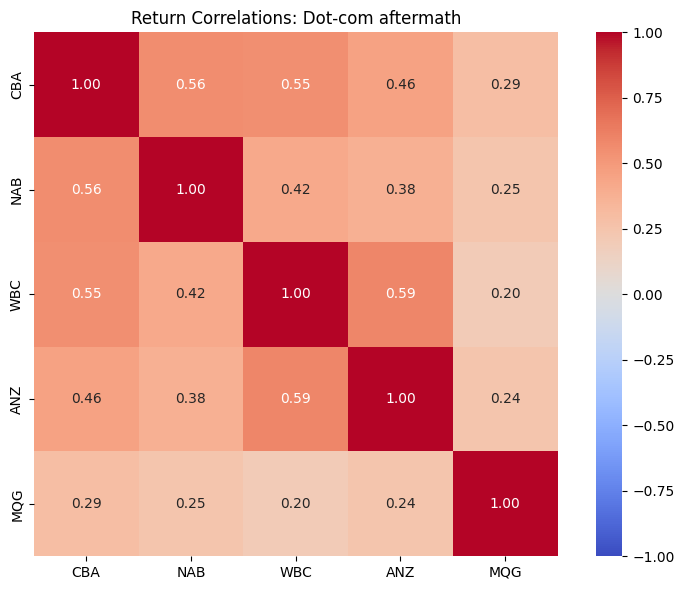

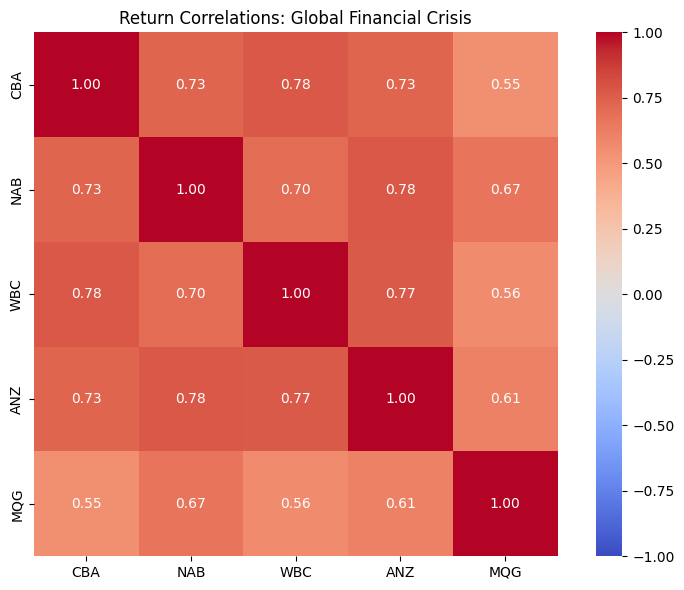

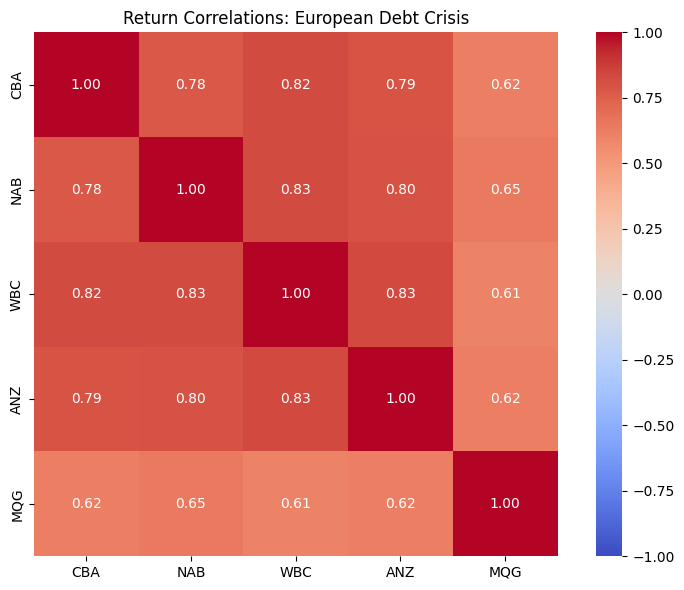

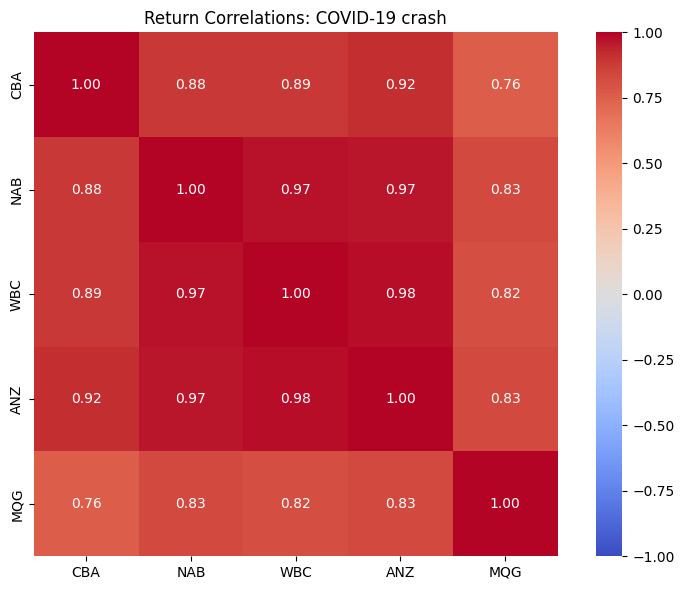

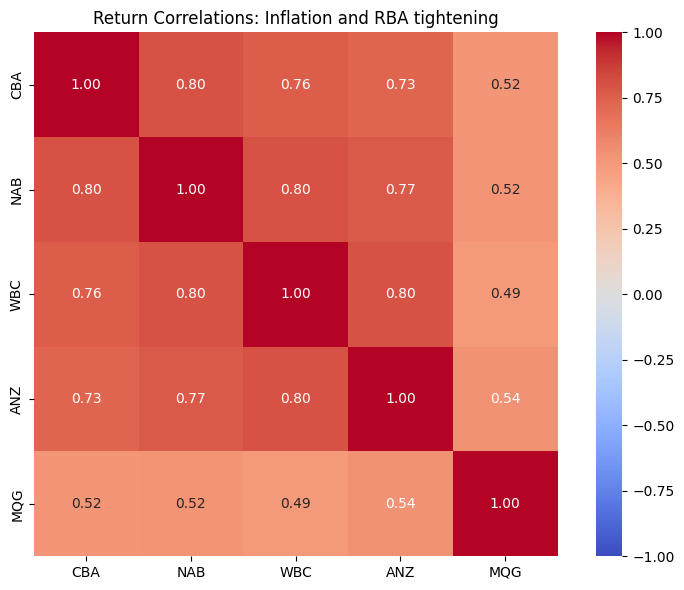

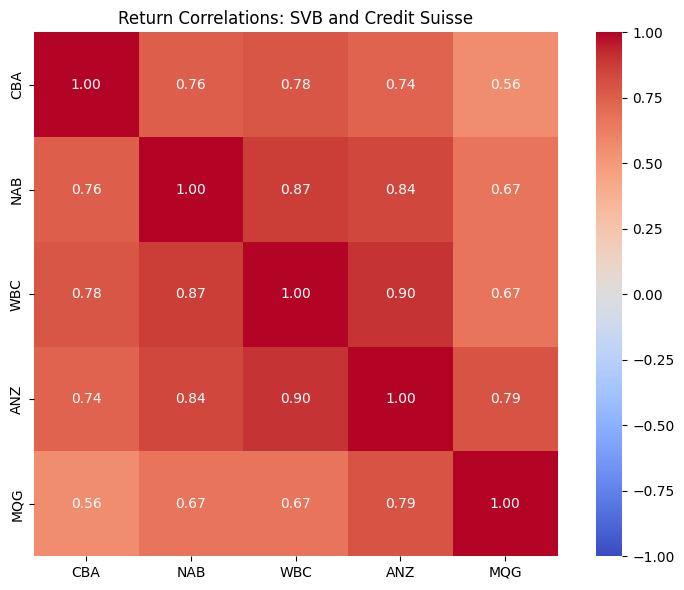

In [32]:
for event, corr_matrix in event_correlations.items():
    plt.figure(figsize=(8, 6))

    sns.heatmap(
        corr_matrix,
        annot=True,
        fmt=".2f",
        vmin=-1,
        vmax=1,
        cmap="coolwarm",
        square=True
    )

    plt.title(
        f"Return Correlations: {event}"
    )

    plt.tight_layout()

    safe_name = (
        event.lower()
        .replace(" ", "_")
        .replace("&", "and")
    )

    plt.savefig(
        figures_folder / f"correlation_{safe_name}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [33]:
running_peaks = price_df.cummax()
drawdowns = (
    price_df / running_peaks
) - 1

drawdowns.head()

,CBA,NAB,WBC,ANZ,MQG
Date,,,,,
2001-07-30,0.000000,0.0,0.000000,0.000000,0.000000
2001-07-31,-0.012056,0.0,-0.015087,-0.018263,0.000000
2001-08-01,0.000000,0.0,0.000000,0.000000,-0.020831
2001-08-02,0.000000,0.0,0.000000,0.000000,0.000000
2001-08-03,-0.021040,0.0,0.000000,0.000000,0.000000


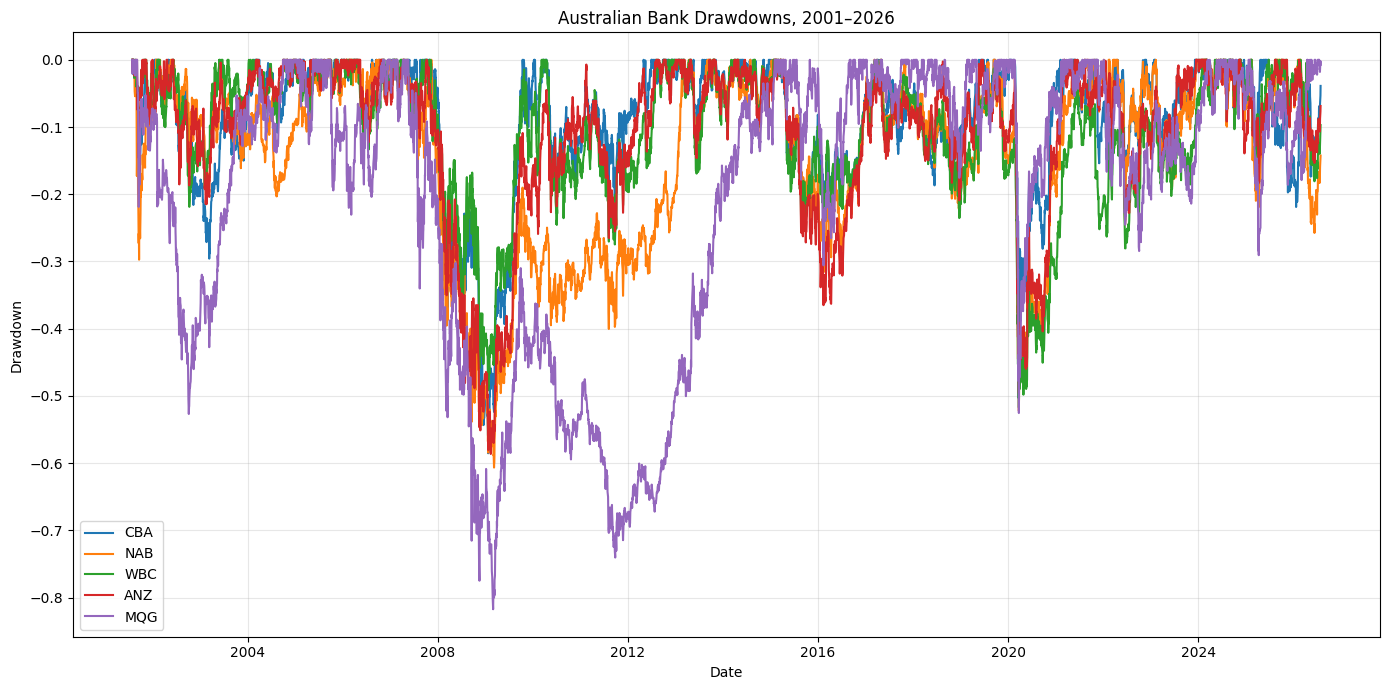

In [34]:
plt.figure(figsize=(14, 7))
for bank in drawdowns.columns:

    plt.plot(
        drawdowns.index,
        drawdowns[bank],
        label=bank
    )

plt.title(
    "Australian Bank Drawdowns, 2001–2026"
)

plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    figures_folder / "bank_drawdowns.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [35]:
print(
    "Price data shape:",
    price_df.shape
)

print(
    "Return data shape:",
    returns.shape
)

print(
    "Rolling volatility shape:",
    rolling_volatility.shape
)

print("\nDate range:")
print("Start:", price_df.index.min())
print("End  :", price_df.index.max())

Price data shape: (6349, 5)
Return data shape: (6348, 5)
Rolling volatility shape: (6348, 5)

Date range:
Start: 2001-07-30 00:00:00
End  : 2026-07-28 00:00:00
